In [1]:
import  numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import t,expon
from collections import Counter
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

In [2]:
df=pd.read_csv("6-Churn_ModellingDataSet.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


{'whiskers': [<matplotlib.lines.Line2D at 0x17beefcc550>,
 'caps': [<matplotlib.lines.Line2D at 0x17beefcee90>,
 'boxes': [<matplotlib.lines.Line2D at 0x17beec96990>],
 'medians': [<matplotlib.lines.Line2D at 0x17beefcf110>],
 'fliers': [<matplotlib.lines.Line2D at 0x17beefcf250>],
 'means': []}

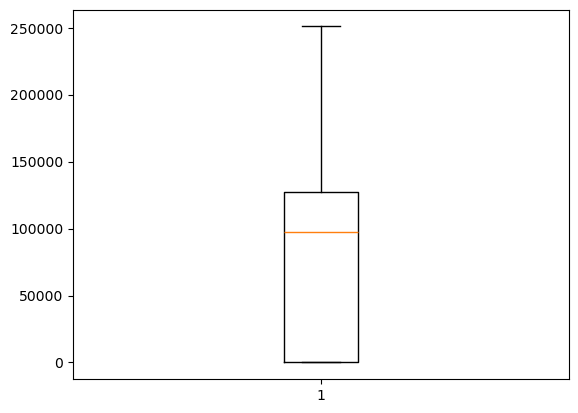

In [10]:
plt.boxplot(df.Balance)

{'whiskers': [<matplotlib.lines.Line2D at 0x17bef0a0050>,
 'caps': [<matplotlib.lines.Line2D at 0x17bef0a02d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x17bef077ed0>],
 'medians': [<matplotlib.lines.Line2D at 0x17bef0a0550>],
 'fliers': [<matplotlib.lines.Line2D at 0x17bef0a0690>],
 'means': []}

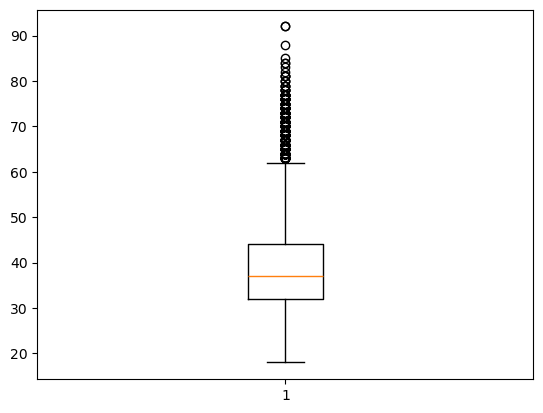

In [11]:
plt.boxplot(df.Age)

In [17]:
exit_counts=df.Exited.value_counts()
exit_counts

Exited
0    7963
1    2037
Name: count, dtype: int64

In [19]:
exit_prop=pd.DataFrame(exit_counts)

In [20]:
exit_prop

,count
Exited,
0,7963
1,2037


In [22]:
exit_prop["proportion"]=exit_prop["count"]/ sum(exit_prop['count'])

In [23]:
exit_prop

,count,proportion
Exited,,
0,7963,0.7963
1,2037,0.2037


{'whiskers': [<matplotlib.lines.Line2D at 0x17b82156350>,
 'caps': [<matplotlib.lines.Line2D at 0x17b821565d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x17b82156210>,
 'medians': [<matplotlib.lines.Line2D at 0x17b82156850>,
 'fliers': [<matplotlib.lines.Line2D at 0x17b82156990>,
 'means': []}

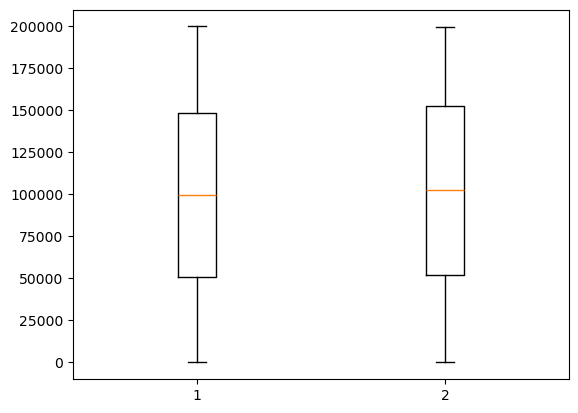

In [30]:
df0=df.iloc[np.where(df.Exited==0)]
df1=df.iloc[np.where(df.Exited==1)]
plt.boxplot([df0.EstimatedSalary,df1.EstimatedSalary])


{'whiskers': [<matplotlib.lines.Line2D at 0x17b8211fd90>,
 'caps': [<matplotlib.lines.Line2D at 0x17b853f0050>,
 'boxes': [<matplotlib.lines.Line2D at 0x17b8211fc50>,
 'medians': [<matplotlib.lines.Line2D at 0x17b8362b4d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x17b82385d10>,
 'means': []}

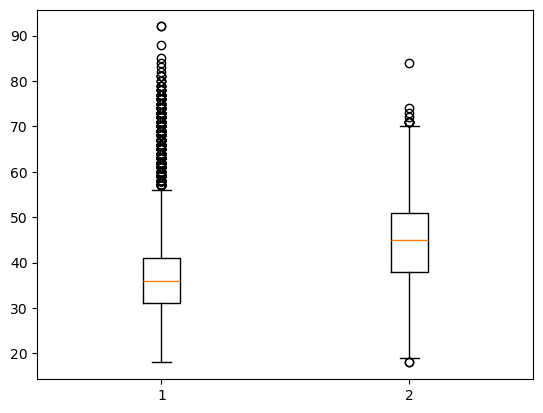

In [31]:
plt.boxplot([df0.Age,df1.Age])

{'whiskers': [<matplotlib.lines.Line2D at 0x17b85749590>,
 'caps': [<matplotlib.lines.Line2D at 0x17b85749810>,
 'boxes': [<matplotlib.lines.Line2D at 0x17b85749450>,
 'medians': [<matplotlib.lines.Line2D at 0x17b85749a90>,
 'fliers': [<matplotlib.lines.Line2D at 0x17b85749bd0>,
 'means': []}

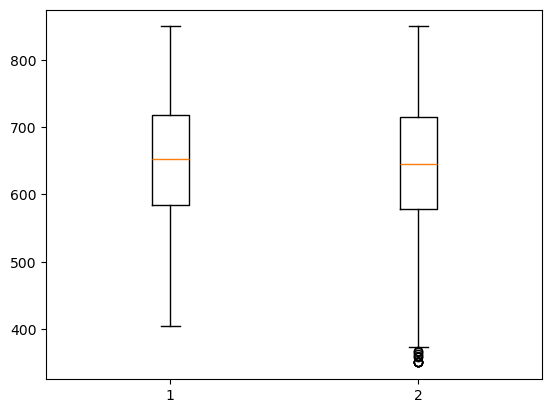

In [32]:
plt.boxplot([df0.CreditScore,df1.CreditScore])

In [38]:
df_400=df.iloc[np.where(df.CreditScore<=400)]

In [41]:
exit_400=df_400.Exited.value_counts()

In [42]:
exit_400

Exited
1    19
Name: count, dtype: int64

In [49]:
df4=pd.crosstab(df.Geography,df.Exited)
df4

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


<Axes: xlabel='Geography'>

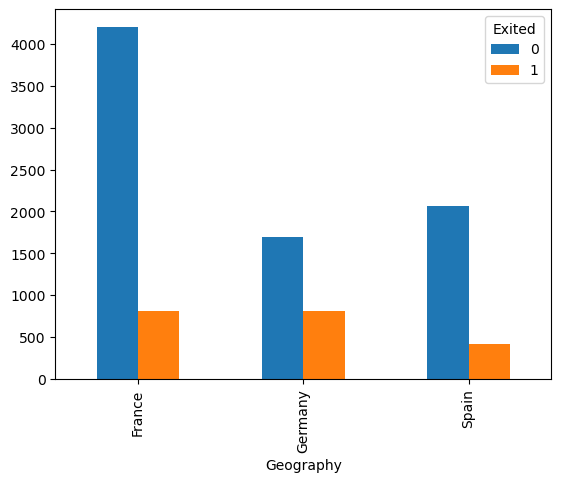

In [50]:
df4.plot(kind="bar")

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [67]:
cc=pd.crosstab(df.Gender,df.Exited)
cc

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [77]:
cc["prop"]=cc[1]/cc[0]+cc[1]

In [84]:
cc=cc.drop(["prop"],axis=1)

In [85]:
cc

Exited,0,1
Gender,,
Female,3404,1139
Male,4559,898


In [ ]:
cc["prop"]=

In [90]:
df.Gender.value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [89]:
1139/(1139+898)

0.5591556210112911

In [92]:
4543/10000

0.4543

In [94]:
geo=pd.crosstab(df.Geography,df.Gender)

In [95]:
geo

Gender,Female,Male
Geography,,
France,2261,2753
Germany,1193,1316
Spain,1089,1388


In [101]:
geo["prop"]=geo["Female"]/(geo["Female"]+geo["Male"])

In [102]:
geo

Gender,Female,Male,prop
Geography,,,
France,2261,2753,0.450937
Germany,1193,1316,0.475488
Spain,1089,1388,0.439645


In [111]:
act=df.pivot_table(index="Exited",columns="IsActiveMember",values="Gender",aggfunc="count")
act

IsActiveMember,0,1
Exited,,
0,3547,4416
1,1302,735


In [110]:
pd.crosstab(df.IsActiveMember,df.Exited)

Exited,0,1
IsActiveMember,,
0,3547,1302
1,4416,735
